# 🌡️ Heatwave & Coldwave EDA — India (1980–2023)
### Extreme Temperature Pattern Discovery using Matplotlib & Seaborn

**Dataset:** 613 events · 13 features · 44 years · Heatwaves & Coldwaves across Indian states

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CHARTS = 'charts/'

df = pd.read_csv('heatcold.csv')
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['month'] = df['start_date'].dt.month
df['month'] = df['month'].fillna(
    ((df['start_doy'].clip(1,365)) / 30.44 + 1).astype(int).clip(1,12)
).astype(int)
df['decade']       = (df['year'] // 10) * 10
decade_labels      = {1980:'1980s',1990:'1990s',2000:'2000s',2010:'2010s',2020:'2020s'}
df['decade_label'] = df['decade'].map(decade_labels)

hw = df[df['event_type']=='Heatwave'].copy()
cw = df[df['event_type']=='Coldwave'].copy()

print(f"Total events : {len(df)}")
print(f"  Heatwaves  : {len(hw)}")
print(f"  Coldwaves  : {len(cw)}")
df.head()

Total events : 613
  Heatwaves  : 387
  Coldwaves  : 226


,event_type,year,start_doy,start_date,duration_days,state,peak_temp_c,temp_anomaly_c,threshold_exceeded_c,estimated_deaths,severity,districts_affected,imd_alert,month,decade,decade_label
0,Coldwave,1980,41,1980-02-10,6,HP,3.2,-6.8,6.8,0,Moderate,16,Orange,2,1980,1980s
1,Heatwave,1980,77,1980-03-17,13,Arunachal Pradesh,44.6,4.6,4.6,84,Moderate,18,Orange,3,1980,1980s
2,Heatwave,1980,93,1980-04-02,8,Andhra Pradesh,45.1,5.1,5.1,96,Moderate,12,Yellow,4,1980,1980s
3,Heatwave,1980,139,1980-05-18,11,Madhya Pradesh,45.1,5.1,5.1,18,Moderate,5,Orange,5,1980,1980s
4,Coldwave,1981,33,1981-02-02,8,Delhi,7.3,-2.7,2.7,4,Mild,4,Orange,2,1980,1980s


---
## 1. Heatwave vs Coldwave Split (Donut Chart)
Shows overall proportion of event types across the full 44-year record. The hollow centre displays total event count — an instant baseline before deeper analysis.

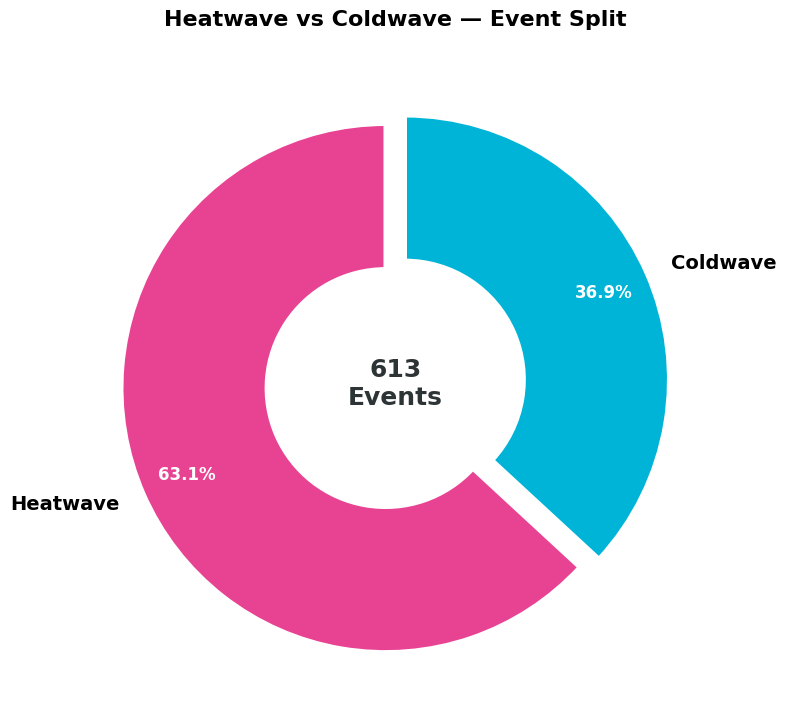

In [2]:
counts = df['event_type'].value_counts()
colors_d = ['#e84393', '#00b4d8']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors_d, startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    explode=[0.04, 0.04])
for t in texts:      t.set_fontsize(14); t.set_fontweight('bold')
for a in autotexts:  a.set_fontsize(12); a.set_color('white'); a.set_fontweight('bold')
ax.text(0, 0, f'{len(df)}\nEvents', ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2d3436')
ax.set_title('Heatwave vs Coldwave — Event Split', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(CHARTS + '01_event_type_donut.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Annual Frequency — Dual Line + Area Chart
Tracks heatwave (pink) and coldwave (blue) counts year-on-year. Shaded fills encode cumulative seasonal pressure. Diverging trends between the two series are a direct climate-change signal.

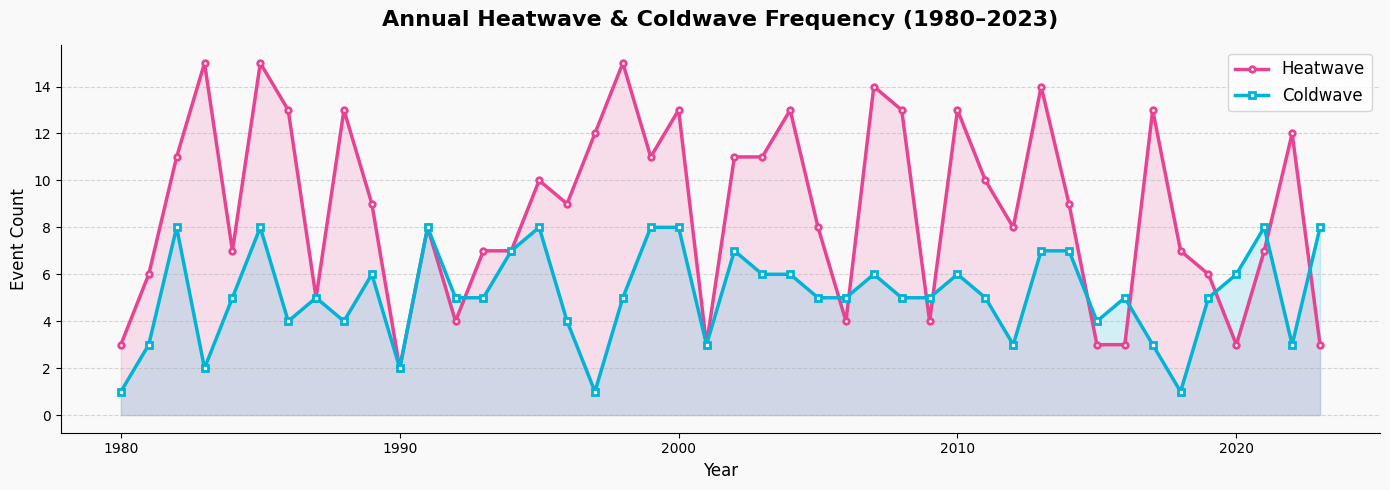

In [3]:
yearly = df.groupby(['year','event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly.index, yearly.get('Heatwave', 0), alpha=0.15, color='#e84393')
ax.fill_between(yearly.index, yearly.get('Coldwave', 0), alpha=0.15, color='#00b4d8')
ax.plot(yearly.index, yearly.get('Heatwave', 0), color='#e84393', lw=2.5,
        marker='o', ms=4, markerfacecolor='white', markeredgewidth=2, label='Heatwave')
ax.plot(yearly.index, yearly.get('Coldwave', 0), color='#00b4d8', lw=2.5,
        marker='s', ms=4, markerfacecolor='white', markeredgewidth=2, label='Coldwave')
ax.set_title('Annual Heatwave & Coldwave Frequency (1980–2023)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12); ax.set_ylabel('Event Count', fontsize=12)
ax.legend(fontsize=12); ax.set_facecolor('#f9f9f9'); fig.patch.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS + '02_yearly_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Monthly Seasonality — Dual Polar Bar Chart
Wraps 12 months onto a wheel with side-by-side bars for each event type. The near-opposite positioning of pink (Mar–Jun) vs blue (Dec–Feb) visually encodes India's entire temperature seasonality in one chart.

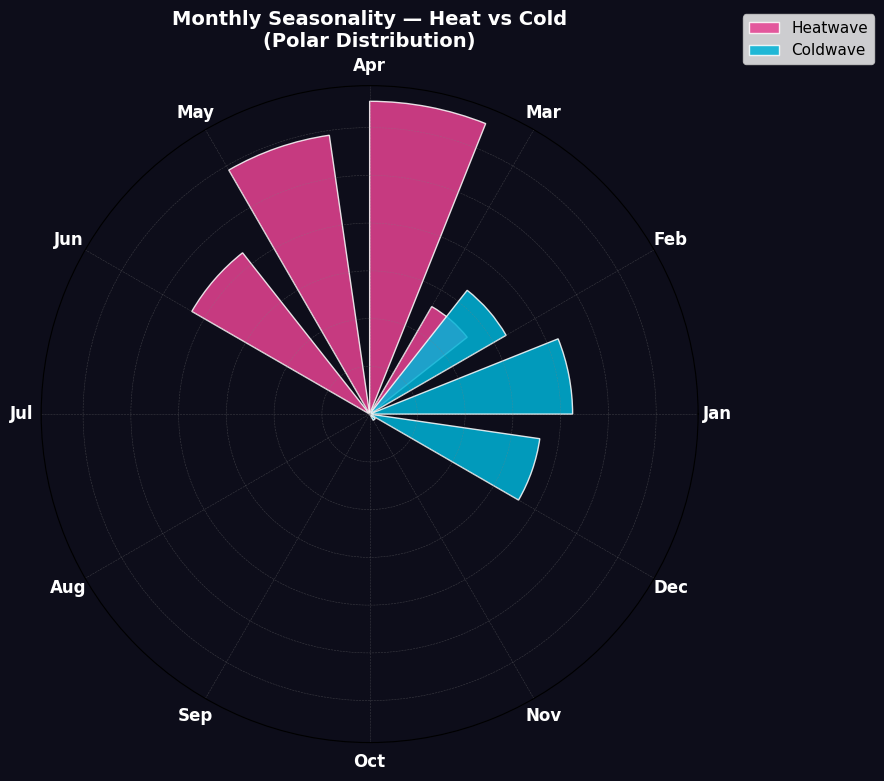

In [4]:
hw_m = hw.groupby('month').size().reindex(range(1,13), fill_value=0)
cw_m = cw.groupby('month').size().reindex(range(1,13), fill_value=0)
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
width  = 0.38

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.bar(angles - width/2, hw_m.values, width=width, color='#e84393',
       alpha=0.85, label='Heatwave', edgecolor='white', linewidth=1)
ax.bar(angles + width/2, cw_m.values, width=width, color='#00b4d8',
       alpha=0.85, label='Coldwave', edgecolor='white', linewidth=1)
ax.set_xticks(angles); ax.set_xticklabels(months_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Monthly Seasonality — Heat vs Cold\n(Polar Distribution)', fontsize=14, fontweight='bold', pad=28)
ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.12), fontsize=11)
ax.grid(color='grey', linestyle='--', linewidth=0.4, alpha=0.4)
fig.patch.set_facecolor('#0d0d1a'); ax.set_facecolor('#0d0d1a'); ax.title.set_color('white')
for label in ax.get_xticklabels(): label.set_color('white')
plt.tight_layout()
plt.savefig(CHARTS + '03_monthly_polar.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## 4. Peak Temperature by Severity — Side-by-side Violin + Strip
Violin width = event density at each temperature. White strip dots = individual events. Comparing the two panels reveals how heatwave severity translates to far higher absolute temperatures than equivalent coldwave severity classes.

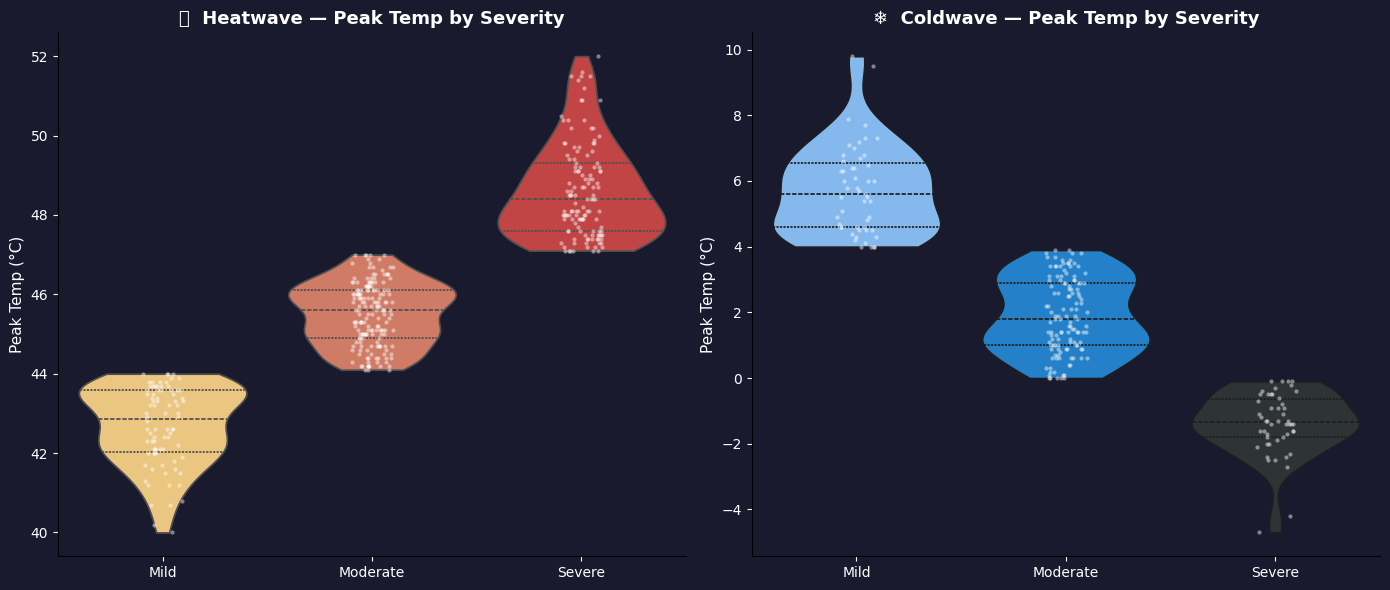

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=hw, y='peak_temp_c', x='severity', order=['Mild','Moderate','Severe'],
               palette=['#fdcb6e','#e17055','#d63031'], ax=axes[0], inner='quartile', cut=0)
sns.stripplot(data=hw, y='peak_temp_c', x='severity', order=['Mild','Moderate','Severe'],
              color='white', alpha=0.45, size=3, jitter=True, ax=axes[0])
axes[0].set_title('🌡️  Heatwave — Peak Temp by Severity', fontsize=13, fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Peak Temp (°C)', fontsize=11)
axes[0].set_facecolor('#1a1a2e'); axes[0].title.set_color('white')
axes[0].yaxis.label.set_color('white'); axes[0].tick_params(colors='white')

sns.violinplot(data=cw, y='peak_temp_c', x='severity', order=['Mild','Moderate','Severe'],
               palette=['#74b9ff','#0984e3','#2d3436'], ax=axes[1], inner='quartile', cut=0)
sns.stripplot(data=cw, y='peak_temp_c', x='severity', order=['Mild','Moderate','Severe'],
              color='white', alpha=0.45, size=3, jitter=True, ax=axes[1])
axes[1].set_title('❄️  Coldwave — Peak Temp by Severity', fontsize=13, fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Peak Temp (°C)', fontsize=11)
axes[1].set_facecolor('#1a1a2e'); axes[1].title.set_color('white')
axes[1].yaxis.label.set_color('white'); axes[1].tick_params(colors='white')

fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(CHARTS + '04_temp_violin.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 5. Deaths vs Temperature Anomaly — Bubble Scatter
Each event sits at the intersection of temperature deviation and death toll. Bubble size = duration. Annotated outliers are the most lethal events in 44 years. The right half (positive anomaly) = heatwaves, left half = coldwaves.

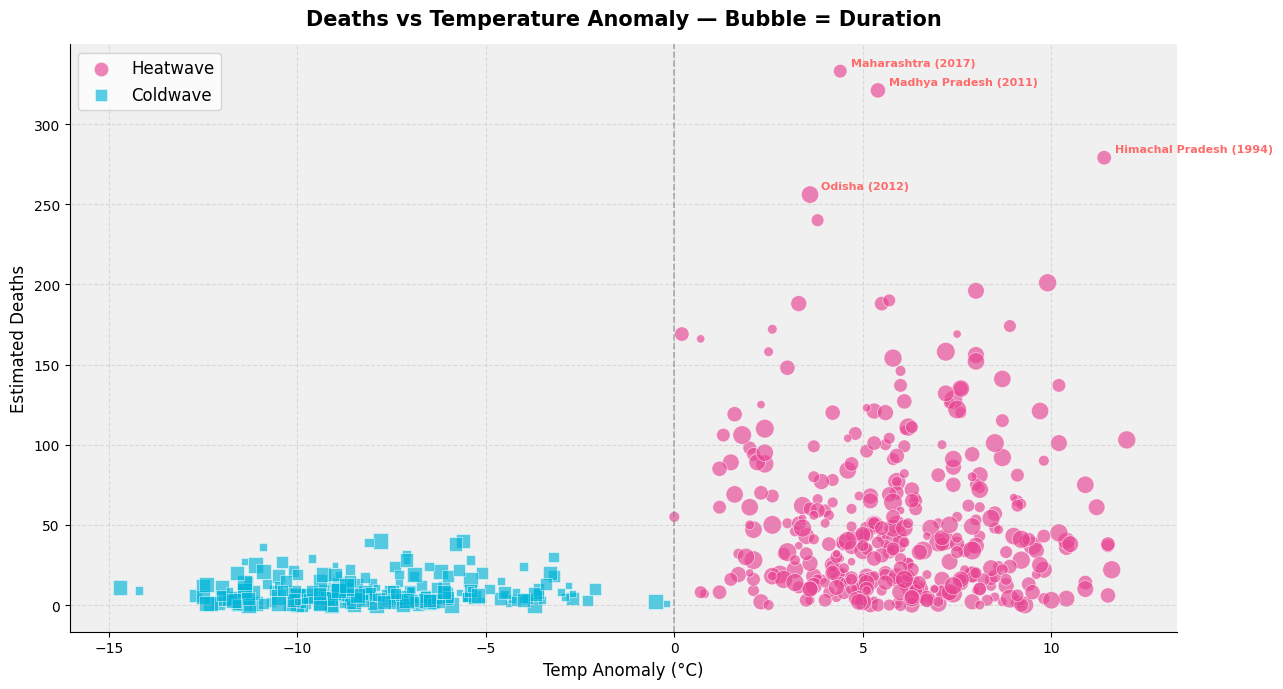

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
for et, color, marker in [('Heatwave','#e84393','o'), ('Coldwave','#00b4d8','s')]:
    sub = df[df['event_type'] == et]
    ax.scatter(sub['temp_anomaly_c'], sub['estimated_deaths'], c=color, alpha=0.65,
               s=sub['duration_days']*12, marker=marker,
               edgecolors='white', linewidths=0.5, label=et)

top4 = df.nlargest(4, 'estimated_deaths')
for _, r in top4.iterrows():
    ax.annotate(f"{r['state']} ({r['year']})", (r['temp_anomaly_c'], r['estimated_deaths']),
                xytext=(8,4), textcoords='offset points', fontsize=8,
                color='#ff6b6b', fontweight='bold')

ax.axvline(0, color='grey', lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('Deaths vs Temperature Anomaly — Bubble = Duration', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Temp Anomaly (°C)', fontsize=12); ax.set_ylabel('Estimated Deaths', fontsize=12)
ax.legend(fontsize=12); ax.set_facecolor('#f0f0f0'); ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(CHARTS + '05_deaths_anomaly_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Year × Month Frequency Heatmap
Every cell = number of events in that year-month pair. Hot cells expose exactly when activity clustered — the bright March-to-June band for heatwaves and the December-February band for coldwaves are clearly visible year after year.

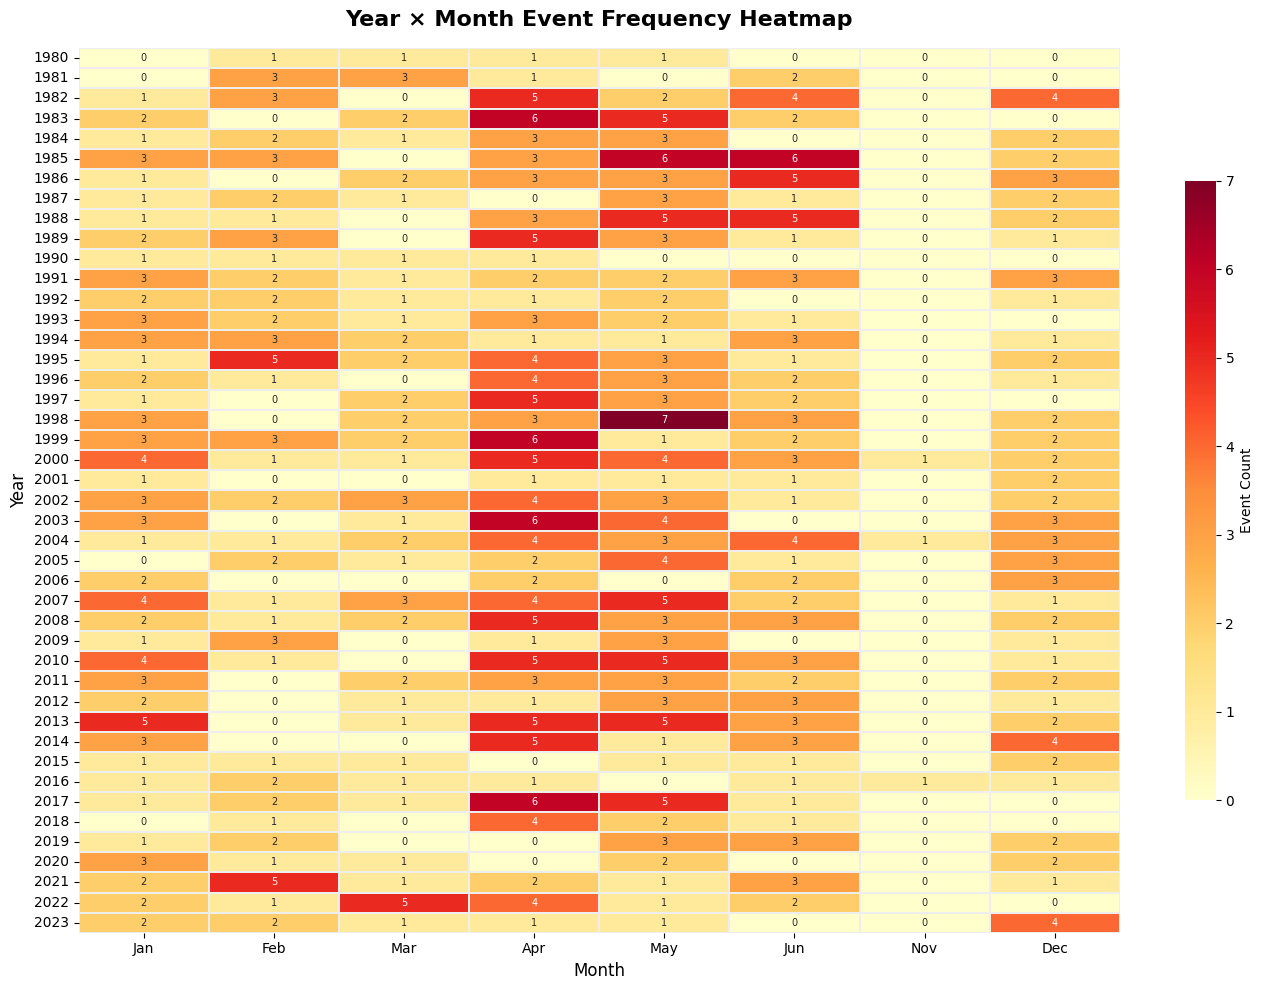

In [7]:
pivot = df.groupby(['year','month']).size().unstack(fill_value=0)
all_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [all_months[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='#eee', ax=ax,
            annot=True, fmt='d', cbar_kws={'label':'Event Count','shrink':0.7},
            annot_kws={'fontsize': 7})
ax.set_title('Year × Month Event Frequency Heatmap', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12); ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHARTS + '06_heatmap_year_month.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Top 10 Deadliest Events — Horizontal Bar Chart
Pink = heatwave, blue = coldwave. Annotated with death count, year, and event type. Reveals which extreme temperature type has historically dominated mortality — and whether any coldwave events breach the top-10 threshold.

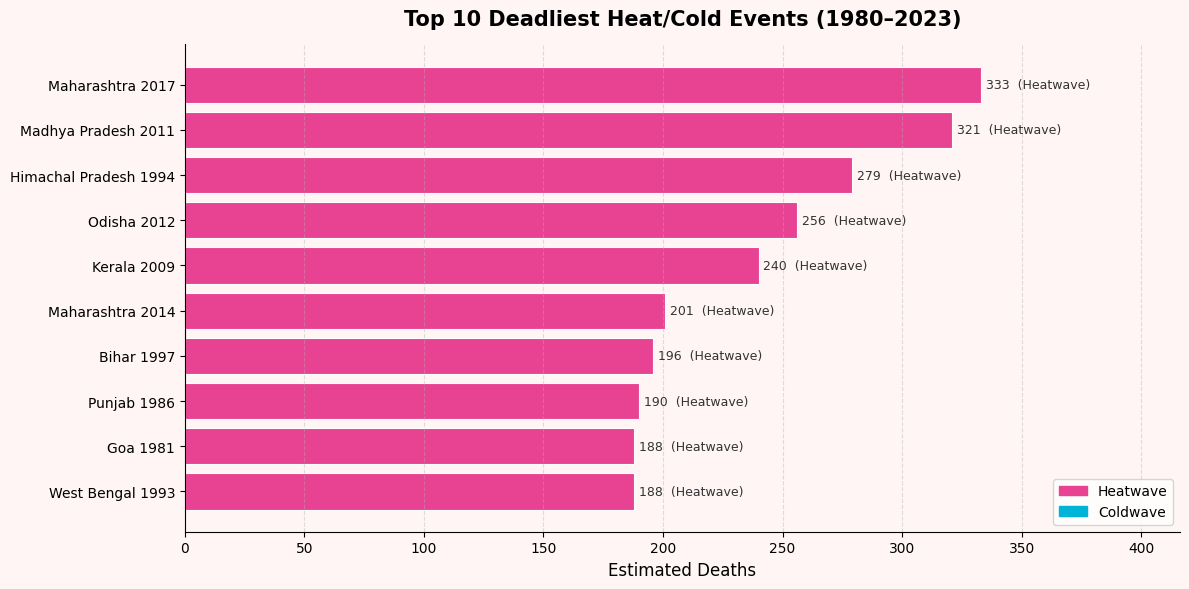

In [8]:
top10 = df.nlargest(10, 'estimated_deaths')[
    ['state','estimated_deaths','year','event_type']
].sort_values('estimated_deaths')
bar_colors = ['#e84393' if et=='Heatwave' else '#00b4d8' for et in top10['event_type']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['state'] + ' ' + top10['year'].astype(str),
               top10['estimated_deaths'], color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{row['estimated_deaths']}  ({row['event_type']})",
            va='center', fontsize=9, color='#333')

hw_patch = mpatches.Patch(color='#e84393', label='Heatwave')
cw_patch = mpatches.Patch(color='#00b4d8', label='Coldwave')
ax.legend(handles=[hw_patch, cw_patch], fontsize=10)
ax.set_title('Top 10 Deadliest Heat/Cold Events (1980–2023)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Estimated Deaths', fontsize=12)
ax.set_xlim(0, top10['estimated_deaths'].max() * 1.25)
ax.set_facecolor('#fff5f5'); fig.patch.set_facecolor('#fff5f5')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '07_top10_deadliest.png', dpi=150, bbox_inches='tight', facecolor='#fff5f5')
plt.show()

---
## 8. Top 15 States — Stacked Horizontal Bar
Stacks heatwave and coldwave event counts per state. A state with balanced colours faces year-round extreme temperature risk; dominance of one colour reveals seasonal risk skew. Directly informs state-level disaster response prioritisation.

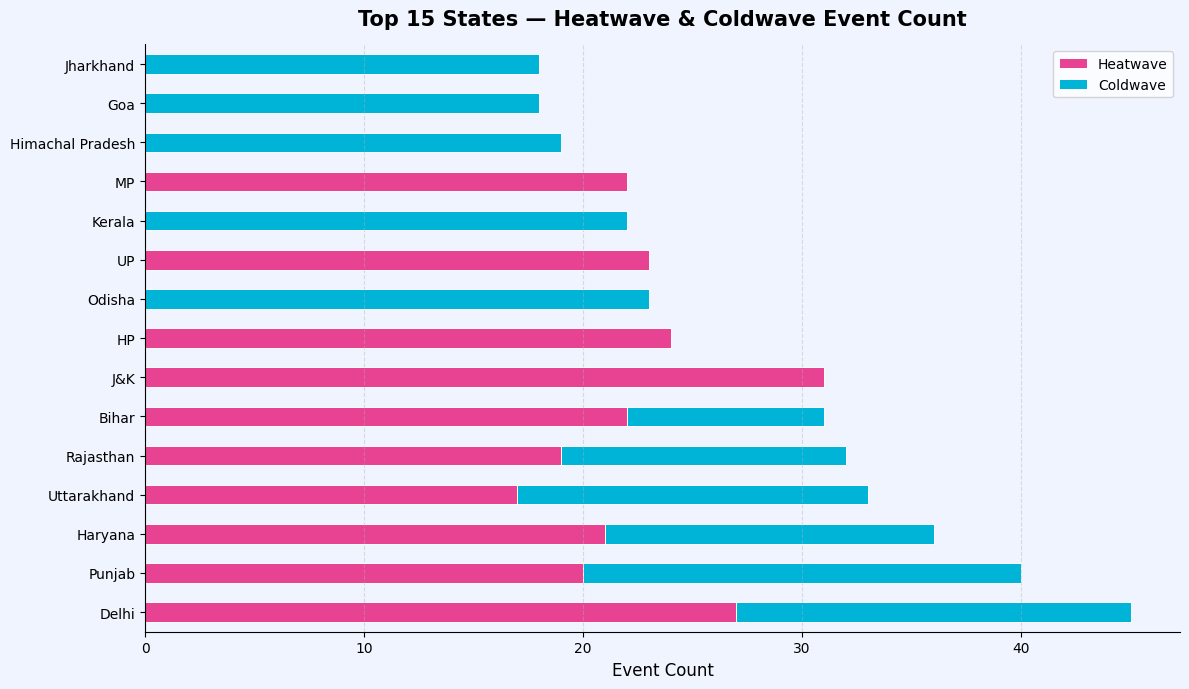

In [9]:
state_counts = df.groupby(['state','event_type']).size().unstack(fill_value=0)
state_counts['total'] = state_counts.sum(axis=1)
top15 = state_counts.nlargest(15, 'total').drop('total', axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
top15.plot(kind='barh', stacked=True, color=['#e84393','#00b4d8'],
           ax=ax, edgecolor='white', linewidth=0.7)
ax.set_title('Top 15 States — Heatwave & Coldwave Event Count', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Event Count', fontsize=12); ax.set_ylabel('')
ax.legend(['Heatwave','Coldwave'], fontsize=10)
ax.set_facecolor('#f0f4ff'); fig.patch.set_facecolor('#f0f4ff')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '08_state_events_stacked.png', dpi=150, bbox_inches='tight', facecolor='#f0f4ff')
plt.show()

---
## 9. Severity vs IMD Alert Level — Cross-tabulation Heatmap
Maps how IMD alert levels (Yellow/Orange/Red) align with actual event severity. Cells where Red alerts were issued for Mild events — or where Severe events got only Yellow — reveal real alert calibration gaps in the warning system.

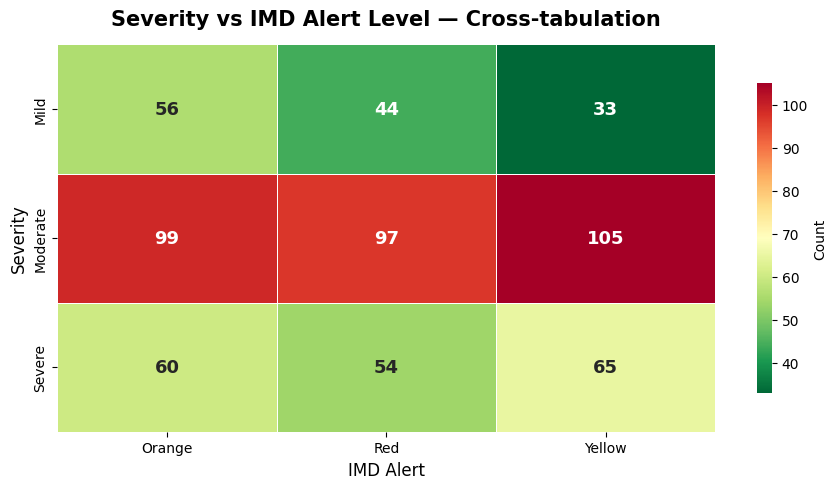

In [10]:
sev_alert = df.groupby(['severity','imd_alert']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(sev_alert, cmap='RdYlGn_r', annot=True, fmt='d', linewidths=0.5,
            cbar_kws={'label':'Count','shrink':0.8},
            annot_kws={'fontsize':13,'fontweight':'bold'}, ax=ax)
ax.set_title('Severity vs IMD Alert Level — Cross-tabulation', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('IMD Alert', fontsize=12); ax.set_ylabel('Severity', fontsize=12)
plt.tight_layout()
plt.savefig(CHARTS + '09_severity_alert_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Temperature Anomaly by Severity & Event Type — Grouped Boxplot
Grouped boxes compare how far temperatures deviated from the historical norm for each severity class and event type. The dashed zero line separates positive (heat) from negative (cold) anomalies — enabling direct symmetry comparison between the two event types.

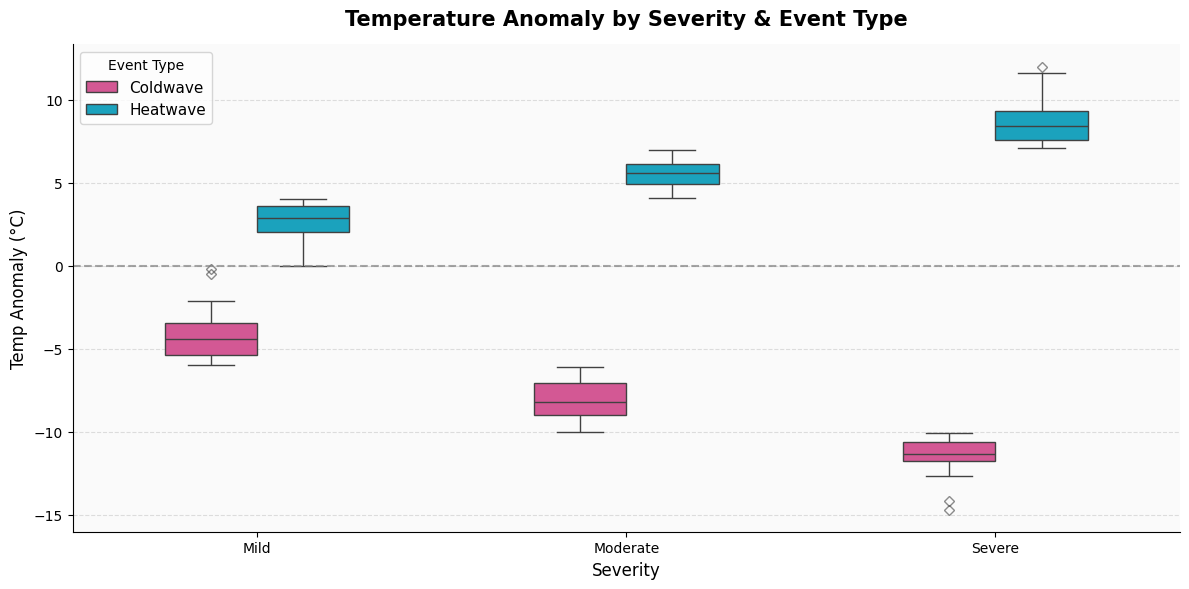

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='severity', y='temp_anomaly_c', hue='event_type',
            order=['Mild','Moderate','Severe'],
            palette=['#e84393','#00b4d8'],
            flierprops=dict(marker='D', markersize=5, alpha=0.6),
            ax=ax, width=0.5)
ax.axhline(0, color='grey', lw=1.5, linestyle='--', alpha=0.7)
ax.set_title('Temperature Anomaly by Severity & Event Type', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Severity', fontsize=12); ax.set_ylabel('Temp Anomaly (°C)', fontsize=12)
ax.legend(title='Event Type', fontsize=11)
ax.set_facecolor('#fafafa'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '10_anomaly_severity_box.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Event Duration Distribution — Overlapping KDE + Histogram
Overlapping histograms and smooth KDE curves for both event types on the same axis. Mean lines are annotated. A longer right tail for one type indicates more chronic multi-week events that accumulate greater physiological and economic damage.

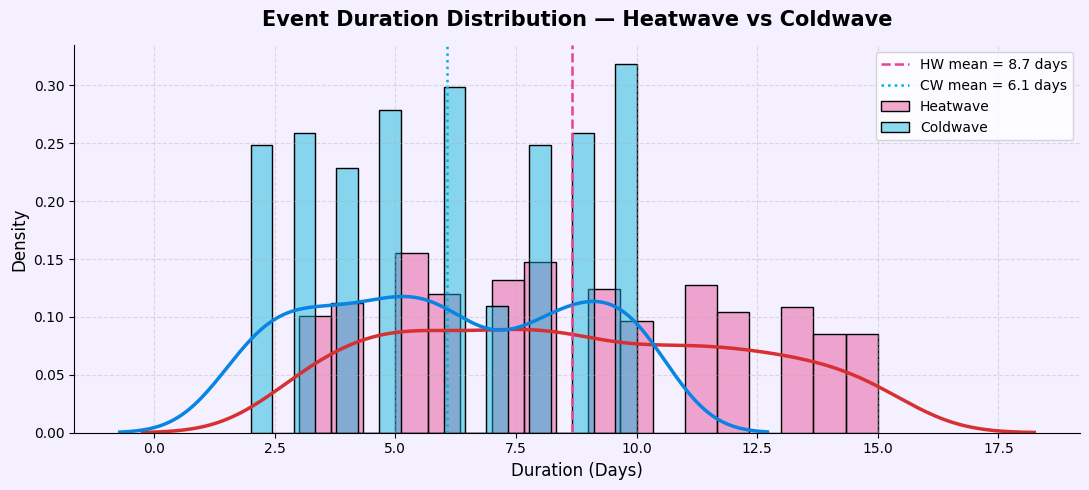

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(hw['duration_days'], bins=18, color='#e84393', alpha=0.45,
             stat='density', ax=ax, label='Heatwave')
sns.histplot(cw['duration_days'], bins=18, color='#00b4d8', alpha=0.45,
             stat='density', ax=ax, label='Coldwave')
sns.kdeplot(hw['duration_days'], color='#d63031', lw=2.5, ax=ax)
sns.kdeplot(cw['duration_days'], color='#0984e3', lw=2.5, ax=ax)
ax.axvline(hw['duration_days'].mean(), color='#e84393', lw=1.8, linestyle='--',
           label=f"HW mean = {hw['duration_days'].mean():.1f} days")
ax.axvline(cw['duration_days'].mean(), color='#00b4d8', lw=1.8, linestyle=':',
           label=f"CW mean = {cw['duration_days'].mean():.1f} days")
ax.set_title('Event Duration Distribution — Heatwave vs Coldwave', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Duration (Days)', fontsize=12); ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
ax.set_facecolor('#f4f0ff'); fig.patch.set_facecolor('#f4f0ff'); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '11_duration_kde.png', dpi=150, bbox_inches='tight', facecolor='#f4f0ff')
plt.show()

---
## 12. Decade-wise Total Deaths — Grouped Bar Chart
Side-by-side bars per decade compare total mortality from heatwaves vs coldwaves. Annotated totals float above each bar. A widening gap between the two types across decades reveals the long-term shift in which extreme temperature type poses the greater mortality risk.

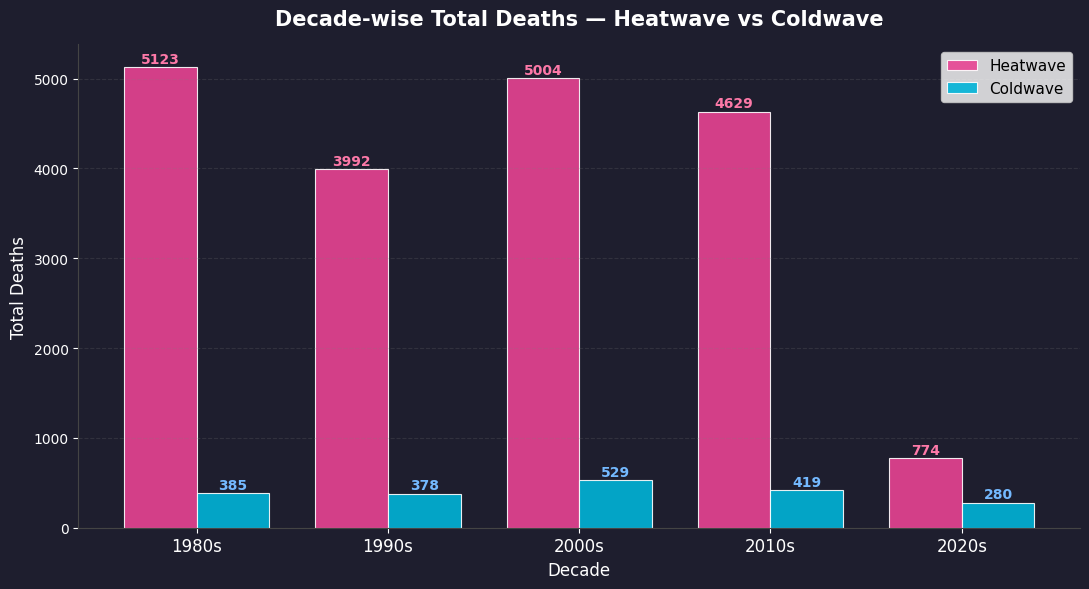

In [13]:
decade_deaths = df.groupby(['decade_label','event_type'])['estimated_deaths'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(decade_deaths)); w = 0.38
b1 = ax.bar(x - w/2, decade_deaths.get('Heatwave', 0), width=w, color='#e84393',
            label='Heatwave', edgecolor='white', linewidth=0.8, alpha=0.9)
b2 = ax.bar(x + w/2, decade_deaths.get('Coldwave', 0), width=w, color='#00b4d8',
            label='Coldwave', edgecolor='white', linewidth=0.8, alpha=0.9)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#fd79a8')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#74b9ff')
ax.set_xticks(x); ax.set_xticklabels(decade_deaths.index, fontsize=12)
ax.set_title('Decade-wise Total Deaths — Heatwave vs Coldwave', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Decade', fontsize=12); ax.set_ylabel('Total Deaths', fontsize=12)
ax.legend(fontsize=11)
ax.set_facecolor('#1e1e2e'); fig.patch.set_facecolor('#1e1e2e')
ax.title.set_color('white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.tick_params(colors='white')
ax.grid(axis='y', linestyle='--', alpha=0.2, color='grey')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
plt.tight_layout()
plt.savefig(CHARTS + '12_decade_deaths_bar.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

---
## 13. Districts Affected vs Deaths — Hexbin Density
Hexagonal bins show where the majority of events cluster in the districts-vs-deaths plane. The dense core near low values shows the typical event; rare hot cells in the upper-right are catastrophic multi-district events that overwhelm state emergency systems.

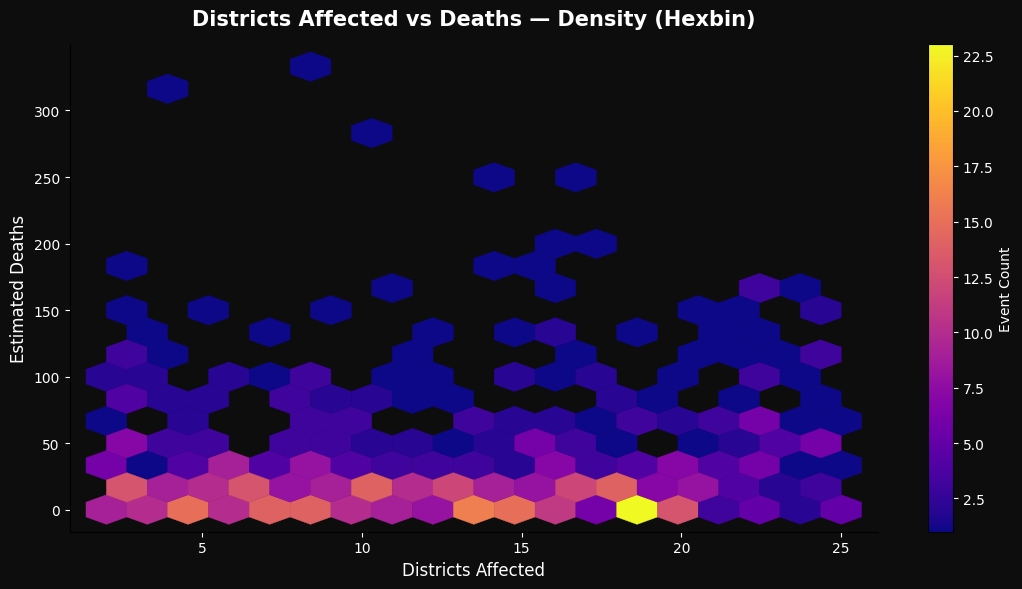

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(df['districts_affected'], df['estimated_deaths'],
               gridsize=18, cmap='plasma', mincnt=1, linewidths=0.3)
cb = fig.colorbar(hb, ax=ax, label='Event Count')
cb.ax.tick_params(labelsize=10)
ax.set_title('Districts Affected vs Deaths — Density (Hexbin)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Districts Affected', fontsize=12); ax.set_ylabel('Estimated Deaths', fontsize=12)
ax.set_facecolor('#0d0d0d'); fig.patch.set_facecolor('#0d0d0d')
ax.title.set_color('white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.tick_params(colors='white')
cb.set_label('Event Count', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
plt.tight_layout()
plt.savefig(CHARTS + '13_districts_deaths_hexbin.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 14. Correlation Matrix — All Numerical Features
Lower-triangular heatmap across 6 key numeric variables. Red = strong positive, blue = strong negative. The near-perfect correlation between temp_anomaly and threshold_exceeded confirms they measure the same signal — a critical insight for avoiding feature redundancy in predictive models.

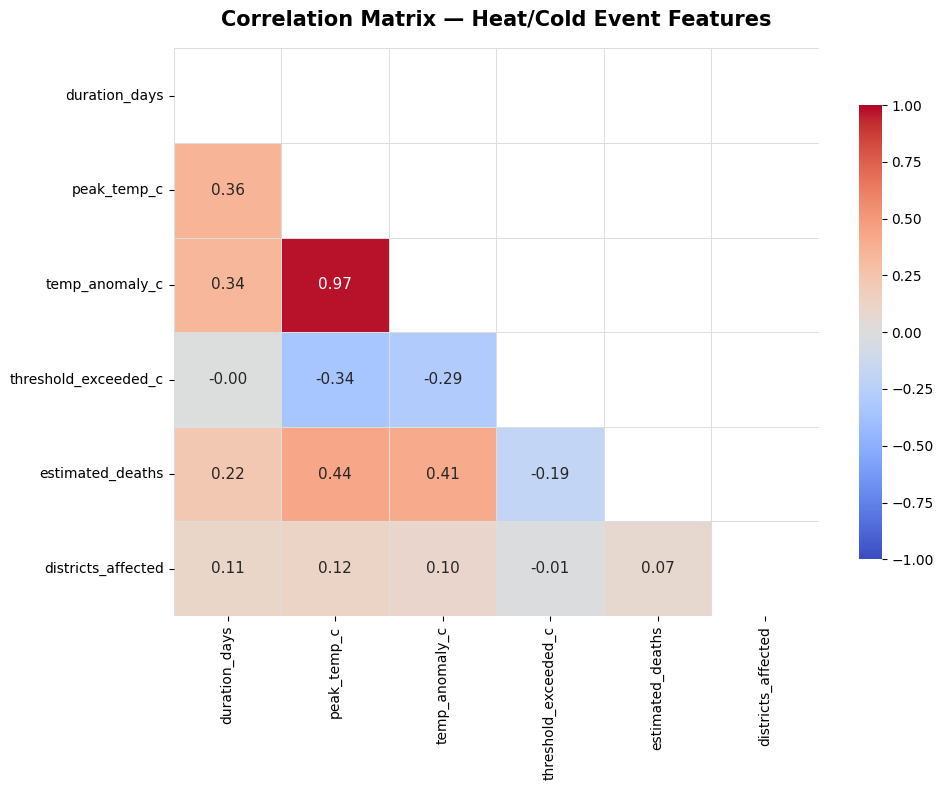

In [15]:
num_cols = ['duration_days','peak_temp_c','temp_anomaly_c',
            'threshold_exceeded_c','estimated_deaths','districts_affected']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd', ax=ax,
            cbar_kws={'shrink':0.8}, annot_kws={'fontsize':11})
ax.set_title('Correlation Matrix — Heat/Cold Event Features', fontsize=15, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(CHARTS + '14_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Pairplot — Key Extreme-Temperature Indicators
Every key variable plotted against every other in a 5×5 grid. Diagonal KDE curves show whether heatwaves and coldwaves form distinct distributions. Bivariate scatter panels expose nonlinear relationships that single correlation values would completely miss.

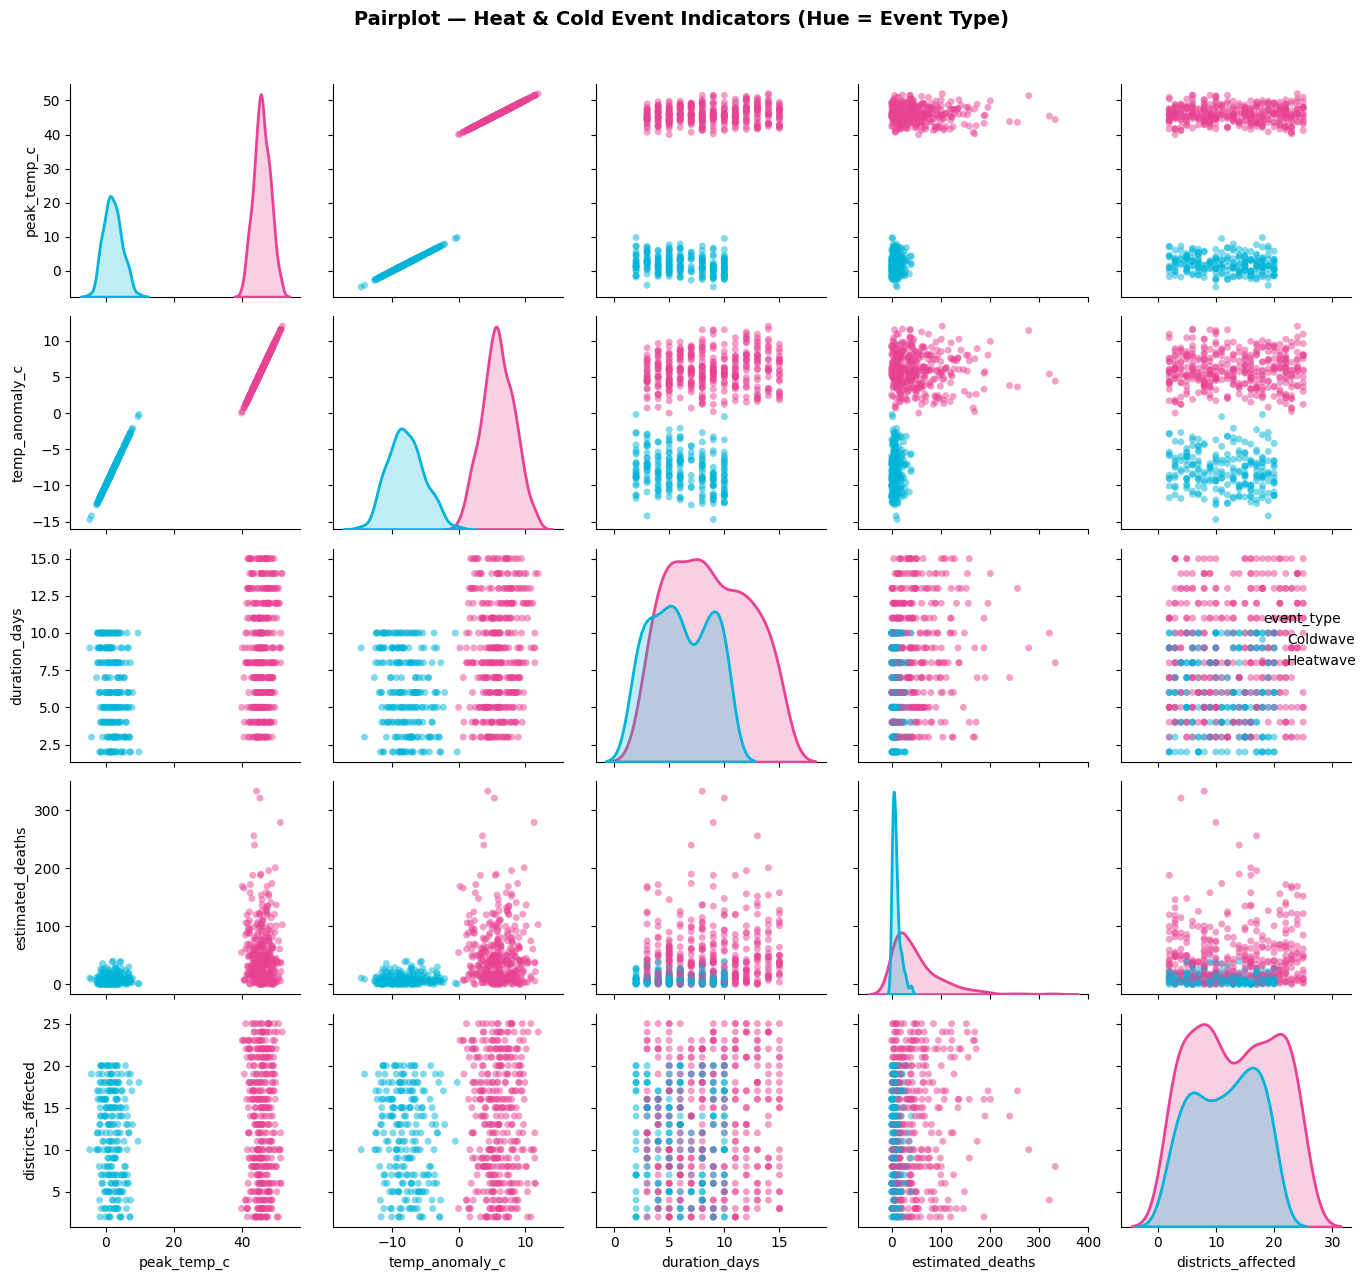

In [16]:
pair_cols = ['peak_temp_c','temp_anomaly_c','duration_days','estimated_deaths','districts_affected']
g = sns.pairplot(df[pair_cols + ['event_type']], hue='event_type',
                 palette={'Heatwave':'#e84393','Coldwave':'#00b4d8'},
                 diag_kind='kde',
                 plot_kws={'alpha':0.5,'edgecolor':'none','s':25},
                 diag_kws={'lw':2})
g.figure.suptitle('Pairplot — Heat & Cold Event Indicators (Hue = Event Type)',
                   y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS + '15_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ✅ All 15 charts saved to `charts/`
Run the cell below to verify all files were created.

In [17]:
import os
files = sorted(os.listdir(CHARTS))
print(f"Total charts saved: {len(files)}")
for f in files:
    size_kb = os.path.getsize(CHARTS + f) // 1024
    print(f"  {f}  ({size_kb} KB)")

Total charts saved: 26
  01_category_distribution.png  (53 KB)
  01_event_type_donut.png  (59 KB)
  02_yearly_frequency.png  (159 KB)
  03_monthly_polar.png  (197 KB)
  04_temp_violin.png  (143 KB)
  04_wind_violin.png  (141 KB)
  05_deaths_anomaly_scatter.png  (243 KB)
  05_deaths_damage_scatter.png  (165 KB)
  06_heatmap_year_month.png  (153 KB)
  07_basin_category_stacked.png  (60 KB)
  07_top10_deadliest.png  (106 KB)
  08_state_events_stacked.png  (65 KB)
  08_top10_deadliest.png  (93 KB)
  09_correlation_heatmap.png  (127 KB)
  09_severity_alert_heatmap.png  (45 KB)
  10_anomaly_severity_box.png  (45 KB)
  10_wind_pressure_scatter.png  (112 KB)
  11_duration_kde.png  (102 KB)
  11_landfall_donut.png  (115 KB)
  12_decade_deaths_bar.png  (63 KB)
  12_surge_kde.png  (75 KB)
  13_districts_deaths_hexbin.png  (111 KB)
  13_duration_track_hexbin.png  (80 KB)
  14_correlation_heatmap.png  (85 KB)
  14_decade_damage_box.png  (57 KB)
  15_pairplot.png  (609 KB)
